In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model # Added Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D # Added GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2 # Added MobileNetV2

2026-05-16 18:07:05.430222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778954825.652715      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778954825.724236      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778954826.233555      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778954826.233605      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778954826.233608      57 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_DIR = "/kaggle/input/leaf-vs-non-leaf-images"

In [3]:
print(os.listdir(DATASET_DIR))

['non_leaf', 'leaf']


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,          # Rotate images by up to 20 degrees
    width_shift_range=0.2,      # Shift images horizontally by up to 20% of the width
    height_shift_range=0.2,     # Shift images vertically by up to 20% of the height
    shear_range=0.2,            # Apply shear transformation
    zoom_range=0.2,             # Zoom in or out by up to 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'         # Fill in new pixels created by transformations
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 10400 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


In [6]:
# Load the MobileNetV2 model pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers so they are not updated during the first phase of training
base_model.trainable = False

# Add a new classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Binary classification

# Create the new model
model = Model(inputs=base_model.input, outputs=predictions)

print("Fine-tuned MobileNetV2 model created.")

I0000 00:00:1778954877.425729      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778954877.432249      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fine-tuned MobileNetV2 model created.


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping] # Add the callback to the fit function
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778954888.980219     146 service.cc:152] XLA service 0x7e5bc81428c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778954888.980274     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778954888.980281     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778954890.232466     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-16 18:08:18.543781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:08:18.680056: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778954900.896463     146 device_co

 36/325 ━━━━━━━━━━━━━━━━━━━━ 4:40 969ms/step - accuracy: 0.8246 - loss: 0.3639

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.9438 - loss: 0.1332

2026-05-16 18:14:52.427456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:14:52.586030: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:14:52.721624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


325/325 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.9439 - loss: 0.1330 - val_accuracy: 0.9277 - val_loss: 0.2104
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 235s 723ms/step - accuracy: 0.9881 - loss: 0.0357 - val_accuracy: 0.9604 - val_loss: 0.1188
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 252s 774ms/step - accuracy: 0.9927 - loss: 0.0193 - val_accuracy: 0.9615 - val_loss: 0.1175
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 234s 719ms/step - accuracy: 0.9935 - loss: 0.0190 - val_accuracy: 0.9585 - val_loss: 0.1159
Epoch 5/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 232s 715ms/step - accuracy: 0.9954 - loss: 0.0154 - val_accuracy: 0.9712 - val_loss: 0.1032
Epoch 6/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 225s 692ms/step - accuracy: 0.9946 - loss: 0.0139 - val_accuracy: 0.9712 - val_loss: 0.0945
Epoch 7/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 223s 687ms/step - accuracy: 0.9942 - loss: 0.0170 - val_accuracy: 0.9523 - val_loss: 0.1892
Epoch 8/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 235s 723ms/step - accuracy: 0.9968 - loss: 0.0085 

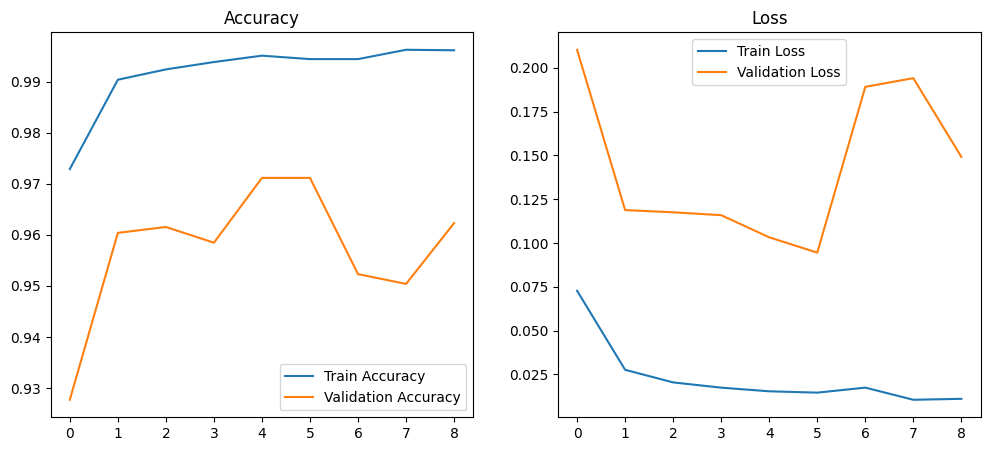

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [10]:
val_loss, val_accuracy = model.evaluate(val_generator)

print(f"\nFinal Validation Accuracy: {val_accuracy * 100:.2f}%")

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc * 100:.2f}%")
print(f"Final Validation Accuracy (Last Epoch): {val_acc * 100:.2f}%")

best_val_acc = max(history.history['val_accuracy'])
print(f"Best Validation Accuracy Achieved: {best_val_acc * 100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 55s 675ms/step - accuracy: 0.9675 - loss: 0.0913

Final Validation Accuracy: 96.62%
Final Training Accuracy: 99.62%
Final Validation Accuracy (Last Epoch): 96.23%
Best Validation Accuracy Achieved: 97.12%


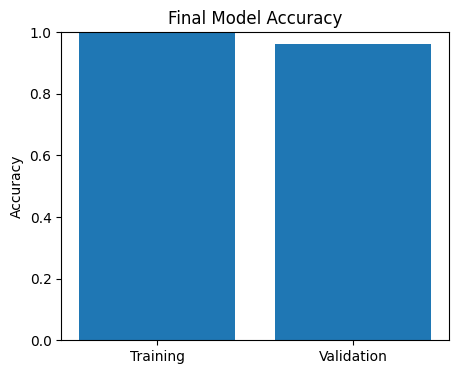

In [11]:
plt.figure(figsize=(5,4))
plt.bar(['Training', 'Validation'], [train_acc, val_acc])
plt.title('Final Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

In [12]:
print("\nClass Indices:")
print(train_generator.class_indices)


Class Indices:
{'leaf': 0, 'non_leaf': 1}


In [13]:
class_names = ['leaf', 'non_leaf']

In [14]:
import numpy as np

def predict(model, img):
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0][0]

    if prediction > 0.5:
        predicted_class = class_names[1]
        confidence = prediction * 100
    else:
        predicted_class = class_names[0]
        confidence = (1 - prediction) * 100

    return predicted_class, round(confidence, 2)

In [15]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 13000 files belonging to 2 classes.


2026-05-16 18:47:29.657778: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:47:29.814602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 18:47:29.947063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


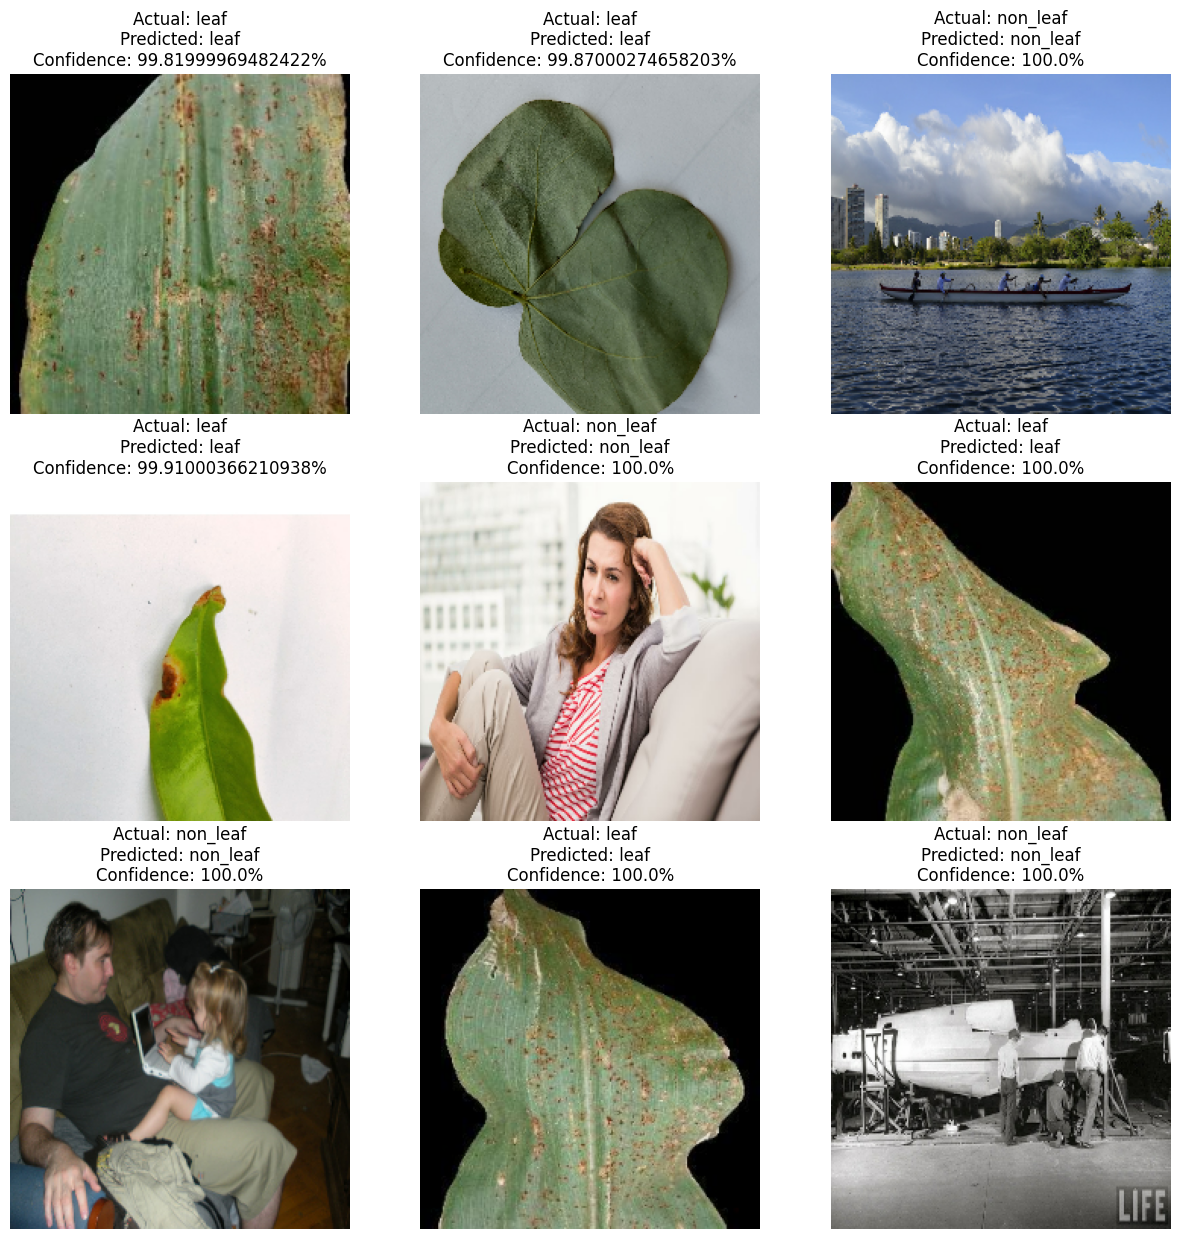

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence}%"
        )

        plt.axis("off")

plt.show()

In [17]:
model.save("leaf_vs_non_leaf_model_2.keras")